# Description

# Modules

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [2]:
LV_NAME = "LV892"

# Paths

These are paths to folder and files where we'll save our figures.

In [3]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv892')

In [4]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv892/lv892-cell_types.svg')

# Load MultiPLIER summary

In [5]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [8]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [9]:
lv_obj.lv_genes.head(20)

,gene_name,LV892,gene_band
0,LPAR6,3.658764,13q14.2
1,MYO7B,3.332468,2q14.3
2,CCR9,2.384444,3p21.31
3,CDK6,2.383156,7q21.2
4,GLRX5,2.204668,14q32.13
5,SEC31B,2.095075,10q24.31
6,STT3B,1.957134,3p23
7,ITGA4,1.859037,2q31.3
8,KCNA6,1.853438,NaN
9,PTGER4,1.675885,5p13.1


Show the pathways our LV is aligned to (neutrophils):

In [10]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

[2025-01-29 20:31:47,901 - numexpr.utils] INFO: Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-01-29 20:31:47,901 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


,pathway,LV index,AUC,p-value,FDR


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [11]:
lv_data = lv_obj.get_experiments_data()

SRP050223, SRP028554, SRP061685, SRP042286, SRP055569, SRP062773, SRP057196, SRP058435, SRP010961, SRP060416, SRP061639, SRP007461, SRP018853, SRP018104, SRP041255, SRP067173, SRP019939, SRP019207, SRP059692, SRP005279, SRP056295, SRP050440, SRP014624, SRP066834, SRP058719, SRP050499, SRP012557, SRP050272, SRP048604, SRP033466, SRP033266, SRP041100, SRP042161, SRP012546, 

/opt/code/libs/data/recount2.py:323: UserWarning: Not all experiments data could be loaded (32 != 34)
  warnings.warn(


In [12]:
lv_data.shape

(5298, 44)

In [13]:
lv_data.head()

tissue treatment compound cell line cell type  \
project   run                                                                
SRP050223 SRR1661716  normal thymus                NaN       NaN       NaN   
          SRR1661717  normal thymus                NaN       NaN       NaN   
          SRR1661718  normal thymus                NaN       NaN       NaN   
          SRR1661719  normal thymus                NaN       NaN       NaN   
          SRR1661720  normal thymus                NaN       NaN       NaN   

                     treatment  age c1 chip id experiment_sample_name  \
project   run                                                           
SRP050223 SRR1661716       NaN  NaN        NaN                    NaN   
          SRR1661717       NaN  NaN        NaN                    NaN   
          SRR1661718       NaN  NaN        NaN                    NaN   
          SRR1661719       NaN  NaN        NaN                    NaN   
          SRR1661720       NaN  NaN        NaN                    NaN   

                     rna subtype activation status  ... disease co-culture  \
project   run                                       ...                      
SRP050223 SRR1661716         NaN               NaN  ...     NaN        NaN   
          SRR1661717         NaN               NaN  ...     NaN        NaN   
          SRR1661718         NaN               NaN  ...     NaN        NaN   
          SRR1661719         NaN               NaN  ...     NaN        NaN   
          SRR1661720         NaN               NaN  ...     NaN        NaN   

                     ectopic expression genotype p/i stimulation  \
project   run                                                      
SRP050223 SRR1661716                NaN      NaN             NaN   
          SRR1661717                NaN      NaN             NaN   
          SRR1661718                NaN      NaN             NaN   
          SRR1661719                NaN      NaN             NaN   
          SRR1661720                NaN      NaN             NaN   

                     infected with patient id subtype tumor group     LV892  
project   run                                                                
SRP050223 SRR1661716           NaN        NaN     NaN         NaN  0.183793  
          SRR1661717           NaN        NaN     NaN         NaN  0.188567  
          SRR1661718           NaN        NaN     NaN         NaN  0.190240  
          SRR1661719           NaN        NaN     NaN         NaN  0.193881  
          SRR1661720           NaN        NaN     NaN         NaN  0.185305  

[5 rows x 44 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [14]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

tissue                    0.027502
treatment                 0.026972
cell line                 0.017691
cancer subtype            0.015495
antibody vendor           0.015351
antibody                  0.014428
sample fraction           0.012861
3' adaptor                0.012290
rna purification          0.010038
agent                     0.010038
sample type               0.009416
all lineage               0.009301
tonsil donor              0.008463
facs gating               0.008463
disease state             0.008147
cytogenetic background    0.007237
bcp all subtype           0.006919
infected with             0.006346
cell type                 0.006247
c1 chip id                0.004989
dtype: float64

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [15]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)

tissue       0.027502
cell line    0.017691
cell type    0.006247
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [16]:
lv_attrs_selected = [
    "tissue",
    "cell type",
]

In [17]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [18]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [19]:
_tmp_seq[0]

tissue cell type     LV892
project   run                                                                
SRP050223 SRR1662002  T cell acute lymphoblastic leukemia       NaN  0.839382
          SRR1662014  T cell acute lymphoblastic leukemia       NaN  0.837657
          SRR1661989  T cell acute lymphoblastic leukemia       NaN  0.834668
          SRR1661994  T cell acute lymphoblastic leukemia       NaN  0.833805
          SRR1662004  T cell acute lymphoblastic leukemia       NaN  0.832123
          SRR1661992  T cell acute lymphoblastic leukemia       NaN  0.831875
          SRR1661988  T cell acute lymphoblastic leukemia       NaN  0.830512
          SRR1662016  T cell acute lymphoblastic leukemia       NaN  0.830365
          SRR1661993  T cell acute lymphoblastic leukemia       NaN  0.829985
          SRR1662009  T cell acute lymphoblastic leukemia       NaN  0.829732
          SRR1662012  T cell acute lymphoblastic leukemia       NaN  0.829366
          SRR1662005  T cell acute lymphoblastic leukemia       NaN  0.828923
          SRR1662008  T cell acute lymphoblastic leukemia       NaN  0.828774
          SRR1662017  T cell acute lymphoblastic leukemia       NaN  0.828598
          SRR1662007  T cell acute lymphoblastic leukemia       NaN  0.828263
          SRR1662010  T cell acute lymphoblastic leukemia       NaN  0.826271
          SRR1662003  T cell acute lymphoblastic leukemia       NaN  0.825759
          SRR1661995  T cell acute lymphoblastic leukemia       NaN  0.825056
          SRR1662000  T cell acute lymphoblastic leukemia       NaN  0.825039
          SRR1662013  T cell acute lymphoblastic leukemia       NaN  0.824795
          SRR1661996  T cell acute lymphoblastic leukemia       NaN  0.823825
          SRR1661990  T cell acute lymphoblastic leukemia       NaN  0.823754
          SRR1662001  T cell acute lymphoblastic leukemia       NaN  0.823479
          SRR1661998  T cell acute lymphoblastic leukemia       NaN  0.823462
          SRR1662015  T cell acute lymphoblastic leukemia       NaN  0.822047

You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [20]:
_tmp_seq[1]

tissue cell type     LV892
project   run                                                                
SRP050223 SRR1662006  T cell acute lymphoblastic leukemia       NaN  0.821967
          SRR1661997  T cell acute lymphoblastic leukemia       NaN  0.821304
          SRR1661991  T cell acute lymphoblastic leukemia       NaN  0.820441
          SRR1662011  T cell acute lymphoblastic leukemia       NaN  0.817988
          SRR1661999  T cell acute lymphoblastic leukemia       NaN  0.814444
          SRR1662114  T cell acute lymphoblastic leukemia       NaN  0.759240
          SRR1662111  T cell acute lymphoblastic leukemia       NaN  0.754835
          SRR1662093  T cell acute lymphoblastic leukemia       NaN  0.750725
          SRR1662107  T cell acute lymphoblastic leukemia       NaN  0.725278
          SRR1662095  T cell acute lymphoblastic leukemia       NaN  0.722244
          SRR1662092  T cell acute lymphoblastic leukemia       NaN  0.719721
          SRR1662106  T cell acute lymphoblastic leukemia       NaN  0.719146
          SRR1662096  T cell acute lymphoblastic leukemia       NaN  0.718831
          SRR1662117  T cell acute lymphoblastic leukemia       NaN  0.718817
          SRR1662084  T cell acute lymphoblastic leukemia       NaN  0.718386
          SRR1662104  T cell acute lymphoblastic leukemia       NaN  0.717699
          SRR1662116  T cell acute lymphoblastic leukemia       NaN  0.717613
          SRR1662112  T cell acute lymphoblastic leukemia       NaN  0.716275
          SRR1662086  T cell acute lymphoblastic leukemia       NaN  0.715723
          SRR1662115  T cell acute lymphoblastic leukemia       NaN  0.715691
          SRR1662105  T cell acute lymphoblastic leukemia       NaN  0.715441
          SRR1662113  T cell acute lymphoblastic leukemia       NaN  0.714950
          SRR1662109  T cell acute lymphoblastic leukemia       NaN  0.714010
          SRR1662085  T cell acute lymphoblastic leukemia       NaN  0.712782
SRP028554 SRR948498                                 blood       NaN  0.712756

Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [ ]:
# list the top 10 samples from this project
lv_data.loc[["SRP015360"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(10)

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [21]:
SELECTED_ATTRIBUTES = [
    "tissue",
    "cell type",
]

## Get a single attribute with "cell type/tissue" information

In [22]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [23]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [24]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [25]:
plot_data.head(20)

tissue     LV892
project   run                                                      
SRP050223 SRR1662002  T cell acute lymphoblastic leukemia  0.839382
          SRR1662014  T cell acute lymphoblastic leukemia  0.837657
          SRR1661989  T cell acute lymphoblastic leukemia  0.834668
          SRR1661994  T cell acute lymphoblastic leukemia  0.833805
          SRR1662004  T cell acute lymphoblastic leukemia  0.832123
          SRR1661992  T cell acute lymphoblastic leukemia  0.831875
          SRR1661988  T cell acute lymphoblastic leukemia  0.830512
          SRR1662016  T cell acute lymphoblastic leukemia  0.830365
          SRR1661993  T cell acute lymphoblastic leukemia  0.829985
          SRR1662009  T cell acute lymphoblastic leukemia  0.829732
          SRR1662012  T cell acute lymphoblastic leukemia  0.829366
          SRR1662005  T cell acute lymphoblastic leukemia  0.828923
          SRR1662008  T cell acute lymphoblastic leukemia  0.828774
          SRR1662017  T cell acute lymphoblastic leukemia  0.828598
          SRR1662007  T cell acute lymphoblastic leukemia  0.828263
          SRR1662010  T cell acute lymphoblastic leukemia  0.826271
          SRR1662003  T cell acute lymphoblastic leukemia  0.825759
          SRR1661995  T cell acute lymphoblastic leukemia  0.825056
          SRR1662000  T cell acute lymphoblastic leukemia  0.825039
          SRR1662013  T cell acute lymphoblastic leukemia  0.824795

You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [26]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [27]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [28]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [29]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [30]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [31]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [32]:
N_TOP_ATTRS = 10

In [33]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [34]:
len(attr_order)

10

In [35]:
attr_order[:5]

['T cell acute lymphoblastic leukemia',
 'blood',
 'bone marrow',
 'Cultured Leukemic Blasts',
 'human primary T-ALL']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

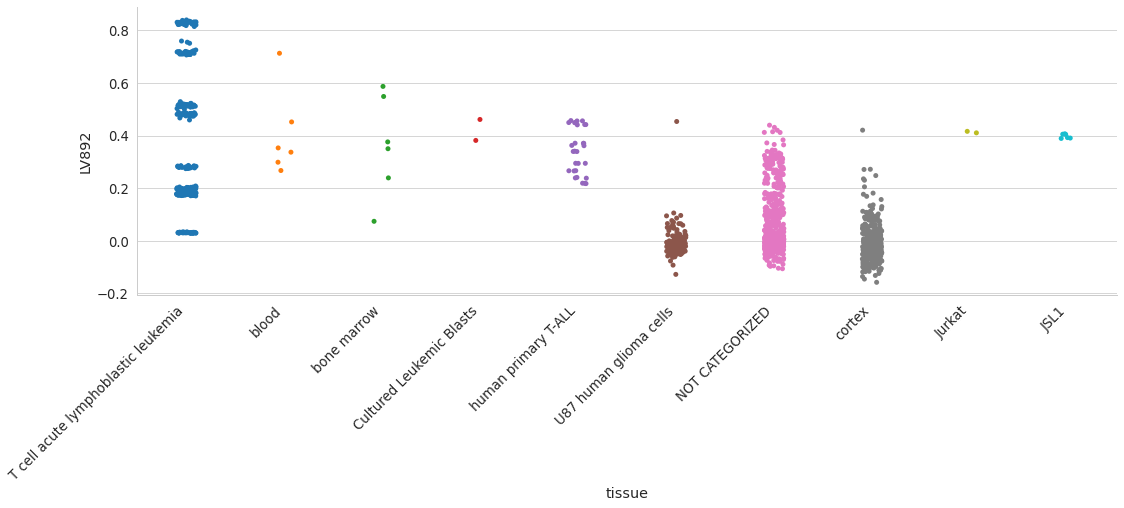

In [36]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

#     plt.savefig(
#         OUTPUT_CELL_TYPE_FILEPATH,
#         bbox_inches="tight",
#         facecolor="white",
#     )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [39]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("NOT CAT")
    ]
    display(_tmp.head(20))

tissue     LV892
project   run                                  
SRP062773 SRR2180203  NOT CATEGORIZED  0.439396
          SRR2180204  NOT CATEGORIZED  0.431100
          SRR2180199  NOT CATEGORIZED  0.420040
          SRR2180198  NOT CATEGORIZED  0.414421
          SRR2180197  NOT CATEGORIZED  0.412011
          SRR2180200  NOT CATEGORIZED  0.411727
SRP061639 SRR2130299  NOT CATEGORIZED  0.383480
          SRR2130298  NOT CATEGORIZED  0.371998
          SRR2130286  NOT CATEGORIZED  0.366050
          SRR2130297  NOT CATEGORIZED  0.364591
          SRR2130288  NOT CATEGORIZED  0.344980
SRP018853 SRR764985   NOT CATEGORIZED  0.344019
SRP018104 SRR651727   NOT CATEGORIZED  0.339709
SRP061639 SRR2130290  NOT CATEGORIZED  0.337221
SRP062773 SRR2180193  NOT CATEGORIZED  0.333817
SRP041255 SRR1248266  NOT CATEGORIZED  0.330189
SRP062773 SRR2180194  NOT CATEGORIZED  0.328807
SRP041255 SRR1248265  NOT CATEGORIZED  0.328732
          SRR1248267  NOT CATEGORIZED  0.327863
SRP061639 SRR2130289  NOT CATEGORIZED  0.326789

We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [41]:
# what is there in these projects?
lv_data.loc[["SRP061639"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

cell line    treatment      sample type     LV892
project   run                                                         
SRP061639 SRR2130299    Jurkat      4 hours  4sU-labeled RNA  0.383480
          SRR2130298    Jurkat      4 hours  4sU-labeled RNA  0.371998
          SRR2130286    Jurkat  Unactivated  4sU-labeled RNA  0.366050
          SRR2130297    Jurkat      4 hours  4sU-labeled RNA  0.364591
          SRR2130288    Jurkat  Unactivated  4sU-labeled RNA  0.344980
          SRR2130290    Jurkat       1 hour  4sU-labeled RNA  0.337221
          SRR2130289    Jurkat       1 hour  4sU-labeled RNA  0.326789
          SRR2130292    Jurkat      2 hours  4sU-labeled RNA  0.322546
          SRR2130296    Jurkat      3 hours  4sU-labeled RNA  0.317262
          SRR2130295    Jurkat      3 hours  4sU-labeled RNA  0.313600
          SRR2130294    Jurkat      3 hours  4sU-labeled RNA  0.305753
          SRR2130291    Jurkat      2 hours  4sU-labeled RNA  0.292294
          SRR2130293    Jurkat      2 hours  4sU-labeled RNA  0.291243
          SRR2130274    Jurkat  Unactivated        total RNA  0.284305
          SRR2130273    Jurkat  Unactivated        total RNA  0.269281
          SRR2130272    Jurkat  Unactivated        total RNA  0.266310
          SRR2130281    Jurkat      3 hours        total RNA  0.259957
          SRR2130283    Jurkat      4 hours        total RNA  0.257970
          SRR2130282    Jurkat      3 hours        total RNA  0.257905
          SRR2130276    Jurkat       1 hour        total RNA  0.252945
          SRR2130279    Jurkat      2 hours        total RNA  0.251807
          SRR2130284    Jurkat      4 hours        total RNA  0.249376
          SRR2130285    Jurkat      4 hours        total RNA  0.248762
          SRR2130275    Jurkat       1 hour        total RNA  0.238864
          SRR2130277    Jurkat      2 hours        total RNA  0.237795
          SRR2130278    Jurkat      2 hours        total RNA  0.228666
          SRR2130280    Jurkat      3 hours        total RNA  0.222357

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.